### The data used for this project was retrieved from https://www.kaggle.com/datasets/arnabchaki/laptop-price-prediction

#### This dataset provides a comprehensive collection of information on various laptops, enabling a detailed analysis of their specifications and pricing. It encompasses a wide range of laptops, encompassing diverse brands, models, and configurations, making it a valuable resource for researchers, data analysts, and machine learning enthusiasts interested in the laptop industry.

#### Fields included:

##### Product: The unique identifier or model name of the laptop.
##### Company: Laptop brand.
##### TypeName: Laptop type and functionality.
##### CPU (Central Processing Unit): The processor brand, model, and other relevant details.
##### GPU (Graphics Processing Unit): The graphics card brand, model, and associated specifications.
##### ScreenResolution: As indicated in the name
##### Operating system: As indicated in the name
##### Weight: The weight of each respective laptop in KG
##### inches: The screen size of the laptop
##### RAM (Random Access Memory): The amount of memory available for multitasking.
##### Storage: The storage type (HDD, SSD) and capacity of the laptop.
##### Price in Euros: The cost of the laptop in Euros.

#### By using this dataset, I was able to explore patterns, trends, and relationships between laptop specifications and their pricing. It serves as an excellent resource for tasks such as price prediction, market analysis, and comparison of different laptop configurations. Whether you are interested in identifying the most cost-effective options or understanding the impact of specific hardware components on laptop prices, this dataset offers abundant possibilities for in-depth exploration.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('Laptop_Specification.csv')
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,OpSys,Weight,Price_euros,Total Sales per Day (euros)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,2679.38
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,899,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575,1150.00
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537,7612.35
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,3607.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,638,1914.00
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,1499,2998.00
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,229,458.00
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,764,764.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      1303 non-null   object 
 1   Product                      1303 non-null   object 
 2   TypeName                     1303 non-null   object 
 3   Inches                       1303 non-null   float64
 4   ScreenResolution             1303 non-null   object 
 5   Cpu                          1303 non-null   object 
 6   Ram (GB)                     1303 non-null   int64  
 7   Memory                       1303 non-null   object 
 8   Gpu                          1303 non-null   object 
 9   OpSys                        1303 non-null   object 
 10  Weight                       1303 non-null   float64
 11  Price_euros                  1303 non-null   int64  
 12  Total Sales per Day (euros)  1303 non-null   float64
dtypes: float64(3), int

In [4]:
#checking for missing values

df.isnull().sum()

Company                        0
Product                        0
TypeName                       0
Inches                         0
ScreenResolution               0
Cpu                            0
Ram (GB)                       0
Memory                         0
Gpu                            0
OpSys                          0
Weight                         0
Price_euros                    0
Total Sales per Day (euros)    0
dtype: int64

In [5]:
#checking data types

df.dtypes

Company                         object
Product                         object
TypeName                        object
Inches                         float64
ScreenResolution                object
Cpu                             object
Ram (GB)                         int64
Memory                          object
Gpu                             object
OpSys                           object
Weight                         float64
Price_euros                      int64
Total Sales per Day (euros)    float64
dtype: object

## Exploratory Data Analysis

In [6]:
#dropping unneccassry columns

df.drop(columns=['Total Sales per Day (euros)'], inplace=True)

In [7]:
#renaming columns

df.rename(columns={'OpSys': 'Operating System', 'Price_euros': 'Price'}, inplace=True)

In [8]:
# laptops count based on the company

df['Company'].value_counts().to_frame()

,Company
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9
Razer,7


In [9]:
# most common RAM in the laptops

df['Ram (GB)'].value_counts().to_frame()

,Ram (GB)
8,619
4,375
16,200
6,41
12,25
2,22
32,17
24,3
64,1


In [10]:
import plotly.express as px

# a pie chart detailing the RAM count for the laptops in the data
ram = df['Ram (GB)'].value_counts()

fig = px.pie(ram, values=ram.values, names=ram.index, title='Laptop By RAM Size', width=600)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [11]:
#laptop price according to RAM

most_expensive_laptop=pd.DataFrame(df.groupby('Ram (GB)')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_laptop

,Ram (GB),Price
0,32,6099
1,16,4389
2,64,3975
3,8,3949
4,24,2968
5,12,2299
6,4,1799
7,6,949
8,2,379


In [12]:
#laptop price according to maker(company)

most_expensive_company=pd.DataFrame(df.groupby('Company')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_company

,Company,Price
0,Razer,6099
1,Lenovo,4899
2,HP,4389
3,Asus,3975
4,Dell,3659
5,Apple,2858
6,Toshiba,2799
7,MSI,2799
8,Acer,2599
9,Microsoft,2589


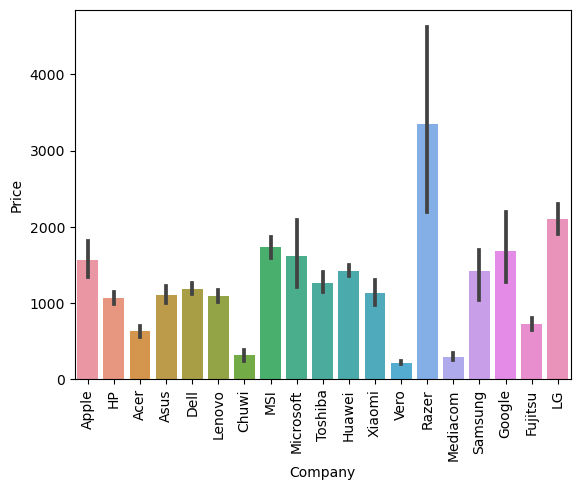

In [13]:
# Razer laptops are the most expensive laptops
# Vero laptops are the least expensive laptops

sns.barplot(x=df['Company'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [14]:
#laptop price according to laptop type=
most_expensive_company = pd.DataFrame(df.groupby('Company')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_company

,Company,Price
0,Razer,6099
1,Lenovo,4899
2,HP,4389
3,Asus,3975
4,Dell,3659
5,Apple,2858
6,Toshiba,2799
7,MSI,2799
8,Acer,2599
9,Microsoft,2589


In [15]:
most_expensive_type=pd.DataFrame(df.groupby('TypeName')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_type

,TypeName,Price
0,Gaming,6099
1,Notebook,4899
2,Workstation,4389
3,Ultrabook,3100
4,2 in 1 Convertible,2824
5,Netbook,1908


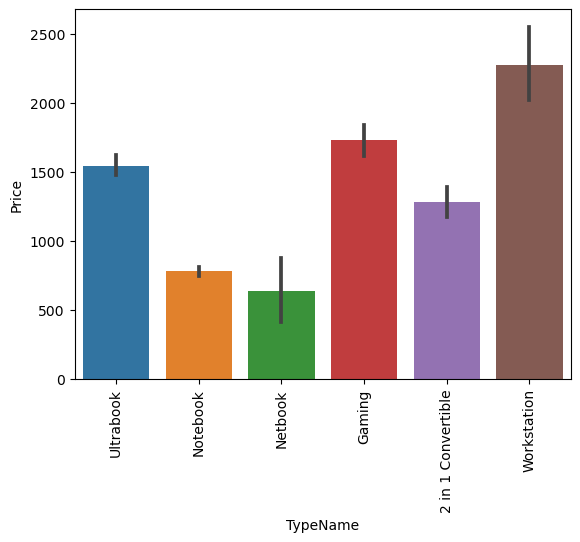

In [16]:
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [17]:
most_expensive_inches=pd.DataFrame(df.groupby('Inches')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_inches

,Inches,Price
0,17.3,6099
1,15.6,4899
2,14.0,3499
3,12.5,3100
4,15.4,2858
5,18.4,2799
6,13.3,2799
7,13.5,2589
8,12.3,2199
9,13.9,2099


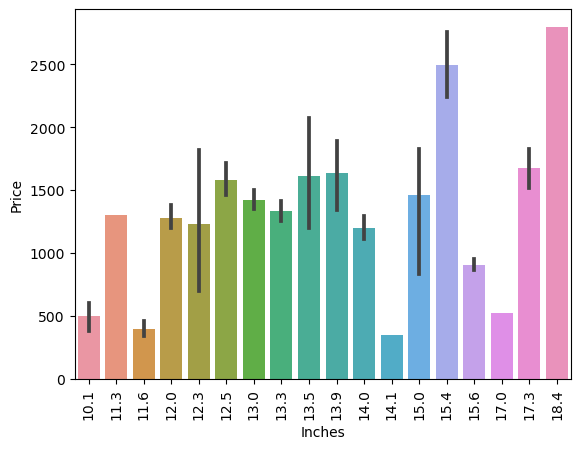

In [18]:
sns.barplot(x=df['Inches'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [19]:
most_expensive_cpu=pd.DataFrame(df.groupby('Cpu')['Price'].max()).reset_index().sort_values(by='Price', ascending=False).reset_index().drop('index',axis=1)
most_expensive_cpu

,Cpu,Price
0,Intel Core i7 7820HK 2.9GHz,6099
1,Intel Xeon E3-1535M v6 3.1GHz,4899
2,Intel Xeon E3-1535M v5 2.9GHz,4389
3,Intel Core i7 6820HK 2.7GHz,3975
4,Intel Core i7 6700HQ 2.6GHz,3949
...,...,...
113,Intel Atom Z8350 1.92GHz,265
114,Intel Atom x5-Z8350 1.44GHz,255
115,Intel Atom x5-Z8300 1.44GHz,245
116,Intel Atom X5-Z8350 1.44GHz,211


In [20]:
x = df["Cpu"].value_counts().to_frame('Processor')
x

,Processor
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core M M3-6Y30 0.9GHz,1
AMD A9-Series 9420 2.9GHz,1
Intel Core i3 6006U 2.2GHz,1
AMD A6-Series 7310 2GHz,1


In [21]:
fig = px.bar(x,title = "Most Common CPU", width=800,height=600)

fig.show()

## Feature Engineering

In [22]:
# using the lambda function to create a new column known as CPU Name

df['CPU Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,Operating System,Weight,Price,CPU Name
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,Intel Core i5
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,899,Intel Core i5
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575,Intel Core i5
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537,Intel Core i7
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,638,Intel Core i7
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,1499,Intel Core i7
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,229,Intel Celeron Dual
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,764,Intel Core i7


In [23]:
# creating a python function that will be used to split the newly created columns into their respective processors

def processor(text):
    if text=="Intel Core i7" or text=="Intel Core i5" or text=="Intel Core i3":
        return text
    else:
        if text.split()[0] == "Intel":
            return "Other Intel Processor"
        else:
            return "AMD Processor"

In [24]:
# applying the python function created earlier

df['CPU Brand'] = df['CPU Name'].apply(processor)

<Axes: >

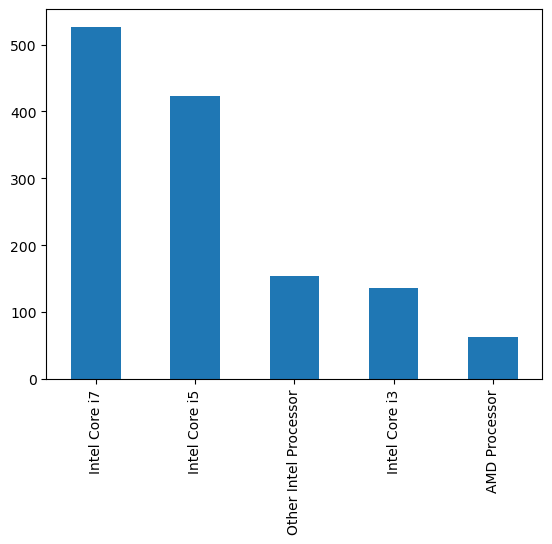

In [25]:
# as shown in the figure below, the most common processor type is Intel Corei7

df['CPU Brand'].value_counts().plot(kind='bar')

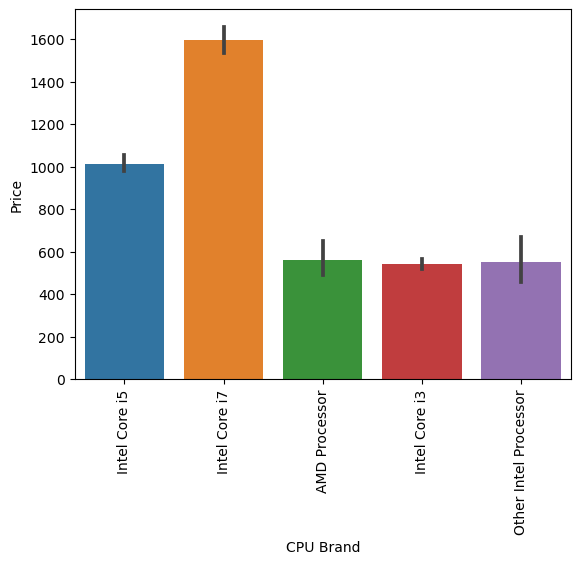

In [26]:
# Furthermore, the intel corei7 is the most expensive laptop type

sns.barplot(x=df['CPU Brand'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [27]:
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,Operating System,Weight,Price,CPU Name,CPU Brand
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,Intel Core i5,Intel Core i5
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,899,Intel Core i5,Intel Core i5
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575,Intel Core i5,Intel Core i5
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537,Intel Core i7,Intel Core i7
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,Intel Core i5,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,638,Intel Core i7,Intel Core i7
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,1499,Intel Core i7,Intel Core i7
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,229,Intel Celeron Dual,Other Intel Processor
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,764,Intel Core i7,Intel Core i7


In [28]:
# creating new columns that splits the memory types in HDD, SSD and Flash storage

top=df['Memory'].value_counts().head(12).index
df=df[df['Memory'].isin(top)]
df['Memory']=df['Memory'].str.replace('GB','')
df['Memory']=df['Memory'].str.replace('TB','000')
first = df["Memory"].str.split("+", n = 1, expand = True)

df['part1']=first[0]
df['part2']=first[1]#we have null values here
# print(df[['part1','part2']])

df['part1']=df['part1'].str.strip()
df['part2'].fillna('0',inplace=True)

In [29]:
# Using lambda function to split the memory column into SSD, HDD and Flash Storage

df["Storage1_SSD"] = df["part1"].apply(lambda x: 1 if "SSD" in x else 0)
df["Storage1_HDD"] = df["part1"].apply(lambda x: 1 if "HDD" in x else 0)
df["Storage1_Flash_Storage"] = df["part1"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df["Storage2_SSD"] = df["part2"].apply(lambda x: 1 if "SSD" in x else 0)
df["Storage2_HDD"] = df["part2"].apply(lambda x: 1 if "HDD" in x else 0)
df["Storage2_Flash_Storage"] = df["part2"].apply(lambda x: 1 if "Flash Storage" in x else 0)

In [30]:
df['part1'] = df['part1'].str.extract('(\d+)').astype(int)
df['part2'] = df['part2'].str.extract('(\d+)').astype(int)
df['part1'].dtype

dtype('int32')

In [31]:
df["SSD"]=(df["part1"]*df["Storage1_SSD"]+df["part2"]*df["Storage2_SSD"])
df["HDD"]=(df["part1"]*df["Storage1_HDD"]+df["part2"]*df["Storage2_HDD"])
df["Flash_Storage"]=(df["part1"]*df["Storage1_Flash_Storage"]+df["part2"]*df["Storage2_Flash_Storage"])

df.drop(columns=['part1', 'part2','Storage1_SSD','Storage1_HDD', 'Storage1_Flash_Storage', 'Storage2_SSD', 'Storage2_HDD', 'Storage2_Flash_Storage'],axis=1,inplace=True)
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,Operating System,Weight,Price,CPU Name,CPU Brand,SSD,HDD,Flash_Storage
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,Intel Core i5,Intel Core i5,128,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575,Intel Core i5,Intel Core i5,256,0,0
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537,Intel Core i7,Intel Core i7,512,0,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,Intel Core i5,Intel Core i5,256,0,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500 HDD,AMD Radeon R5,Windows 10,2.10,400,AMD A9-Series 9420,AMD Processor,0,500,0


In [32]:
# using the lambda function to create a new column known as GPU Brand

df['GPU Brand'] = df['Gpu'].apply(lambda x:x.split()[0])

In [33]:
df

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,Operating System,Weight,Price,CPU Name,CPU Brand,SSD,HDD,Flash_Storage,GPU Brand
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,Intel Core i5,Intel Core i5,128,0,0,Intel
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575,Intel Core i5,Intel Core i5,256,0,0,Intel
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537,Intel Core i7,Intel Core i7,512,0,0,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,Intel Core i5,Intel Core i5,256,0,0,Intel
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500 HDD,AMD Radeon R5,Windows 10,2.10,400,AMD A9-Series 9420,AMD Processor,0,500,0,AMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128 SSD,Intel HD Graphics 520,Windows 10,1.80,638,Intel Core i7,Intel Core i7,128,0,0,Intel
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512 SSD,Intel HD Graphics 520,Windows 10,1.30,1499,Intel Core i7,Intel Core i7,512,0,0,Intel
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64 Flash Storage,Intel HD Graphics,Windows 10,1.50,229,Intel Celeron Dual,Other Intel Processor,0,0,64,Intel
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1000 HDD,AMD Radeon R5 M330,Windows 10,2.19,764,Intel Core i7,Intel Core i7,0,1000,0,AMD


In [34]:
# the most common GPU Brand is intel

n=df['GPU Brand'].str.split(' ',n=1,expand=True)
df['GPU Brand']=n[0]
df['GPU Brand'].value_counts().to_frame()

,GPU Brand
Intel,677
Nvidia,383
AMD,164
ARM,1


In [35]:
# removing unnesccary columns

df.drop(columns=['CPU Name', 'Cpu'],axis=1,inplace=True)
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Ram (GB),Memory,Gpu,Operating System,Weight,Price,CPU Brand,SSD,HDD,Flash_Storage,GPU Brand
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,1340,Intel Core i5,128,0,0,Intel
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,8,256 SSD,Intel HD Graphics 620,No OS,1.86,575,Intel Core i5,256,0,0,Intel
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,2537,Intel Core i7,512,0,0,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,1804,Intel Core i5,256,0,0,Intel
5,Acer,Aspire 3,Notebook,15.6,1366x768,4,500 HDD,AMD Radeon R5,Windows 10,2.10,400,AMD Processor,0,500,0,AMD


In [36]:
df.drop(columns=['Memory',"Gpu"],axis=1,inplace=True)
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Ram (GB),Operating System,Weight,Price,CPU Brand,SSD,HDD,Flash_Storage,GPU Brand
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,1340,Intel Core i5,128,0,0,Intel
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,575,Intel Core i5,256,0,0,Intel
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,2537,Intel Core i7,512,0,0,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,1804,Intel Core i5,256,0,0,Intel
5,Acer,Aspire 3,Notebook,15.6,1366x768,4,Windows 10,2.10,400,AMD Processor,0,500,0,AMD


In [37]:
df.dtypes

Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Ram (GB)              int64
Operating System     object
Weight              float64
Price                 int64
CPU Brand            object
SSD                   int64
HDD                   int64
Flash_Storage         int64
GPU Brand            object
dtype: object

In [38]:
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', 'Full HD 1920x1080',
       'IPS Panel Retina Display 2880x1800', '1366x768',
       'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel Quad HD+ 320

In [39]:
# splitting the screenresolution columns into touchscreen and normal screen

df['TouchScreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df

,Company,Product,TypeName,Inches,ScreenResolution,Ram (GB),Operating System,Weight,Price,CPU Brand,SSD,HDD,Flash_Storage,GPU Brand,TouchScreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,1340,Intel Core i5,128,0,0,Intel,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,8,No OS,1.86,575,Intel Core i5,256,0,0,Intel,0
3,Apple,,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,macOS,1.83,2537,Intel Core i7,512,0,0,AMD,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,macOS,1.37,1804,Intel Core i5,256,0,0,Intel,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,4,Windows 10,2.10,400,AMD Processor,0,500,0,AMD,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,4,Windows 10,1.80,638,Intel Core i7,128,0,0,Intel,1
1299,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,16,Windows 10,1.30,1499,Intel Core i7,512,0,0,Intel,1
1300,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,2,Windows 10,1.50,229,Other Intel Processor,0,0,64,Intel,0
1301,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,6,Windows 10,2.19,764,Intel Core i7,0,1000,0,AMD,0


<Axes: xlabel='TouchScreen', ylabel='Price'>

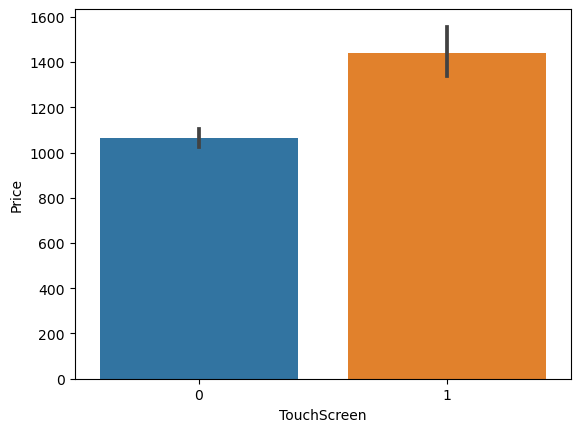

In [40]:
# touchscreen laptops are more expensive than normal screen laptops

sns.barplot(x=df['TouchScreen'],y=df['Price'])

## Modelling

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1225 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1225 non-null   object 
 1   Product           1225 non-null   object 
 2   TypeName          1225 non-null   object 
 3   Inches            1225 non-null   float64
 4   ScreenResolution  1225 non-null   object 
 5   Ram (GB)          1225 non-null   int64  
 6   Operating System  1225 non-null   object 
 7   Weight            1225 non-null   float64
 8   Price             1225 non-null   int64  
 9   CPU Brand         1225 non-null   object 
 10  SSD               1225 non-null   int64  
 11  HDD               1225 non-null   int64  
 12  Flash_Storage     1225 non-null   int64  
 13  GPU Brand         1225 non-null   object 
 14  TouchScreen       1225 non-null   int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 153.1+ KB


In [42]:
# removing unnecassary columns

df.drop(columns=['Product', 'ScreenResolution', 'Operating System', 'Weight'],axis=1,inplace=True)
df.head()

,Company,TypeName,Inches,Ram (GB),Price,CPU Brand,SSD,HDD,Flash_Storage,GPU Brand,TouchScreen
0,Apple,Ultrabook,13.3,8,1340,Intel Core i5,128,0,0,Intel,0
2,HP,Notebook,15.6,8,575,Intel Core i5,256,0,0,Intel,0
3,Apple,Ultrabook,15.4,16,2537,Intel Core i7,512,0,0,AMD,0
4,Apple,Ultrabook,13.3,8,1804,Intel Core i5,256,0,0,Intel,0
5,Acer,Notebook,15.6,4,400,AMD Processor,0,500,0,AMD,0


In [43]:
# one-hot encoding

df = pd.get_dummies(df)
df.head()

,Inches,Ram (GB),Price,SSD,HDD,Flash_Storage,TouchScreen,Company_Acer,Company_Apple,Company_Asus,...,TypeName_Workstation,CPU Brand_AMD Processor,CPU Brand_Intel Core i3,CPU Brand_Intel Core i5,CPU Brand_Intel Core i7,CPU Brand_Other Intel Processor,GPU Brand_AMD,GPU Brand_ARM,GPU Brand_Intel,GPU Brand_Nvidia
0,13.3,8,1340,128,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,15.6,8,575,256,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,15.4,16,2537,512,0,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
4,13.3,8,1804,256,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
5,15.6,4,400,0,500,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0


In [44]:
df.dtypes

Inches                             float64
Ram (GB)                             int64
Price                                int64
SSD                                  int64
HDD                                  int64
Flash_Storage                        int64
TouchScreen                          int64
Company_Acer                         uint8
Company_Apple                        uint8
Company_Asus                         uint8
Company_Chuwi                        uint8
Company_Dell                         uint8
Company_Fujitsu                      uint8
Company_Google                       uint8
Company_HP                           uint8
Company_Huawei                       uint8
Company_LG                           uint8
Company_Lenovo                       uint8
Company_MSI                          uint8
Company_Mediacom                     uint8
Company_Microsoft                    uint8
Company_Razer                        uint8
Company_Samsung                      uint8
Company_Tos

In [45]:
# creating dependent and independing variables

X = df.drop('Price', axis= 1)
y=np.log(df['Price'])

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
# splitting the dataset into training(80%) and testing(20%)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=1234)

In [48]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(980, 40) (245, 40) (980,) (245,)


In [49]:
#pip install xgboost

In [50]:
#pip list

In [51]:
# this is a regression project
# importing scikit learning regressors

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [52]:
# creating a pipeline for the algorithms

pipelines = {
    'rf': make_pipeline(RandomForestRegressor(random_state=1234)),
    'gb': make_pipeline(GradientBoostingRegressor(random_state=1234)),
    'ridge': make_pipeline(Ridge(random_state=1234)),
    'lasso': make_pipeline(Lasso(random_state=1234)),
    'enet': make_pipeline(ElasticNet(random_state=1234)),
    "xg":make_pipeline(XGBRegressor()),
    'knr': make_pipeline(KNeighborsRegressor()),
    'dt': make_pipeline(DecisionTreeRegressor(random_state=1234))
}

In [53]:
# a parameter hypergrid to improve the performance of the algorithm

hypergrid = {
    'rf': {
        'randomforestregressor__n_estimators': [10, 50, 100, 200],
        'randomforestregressor__max_depth': [None, 10, 20, 30],
        'randomforestregressor__min_samples_split': [2, 5, 10],
        'randomforestregressor__min_samples_leaf': [1, 2, 4],
        'randomforestregressor__max_features': ['auto', 'sqrt', 'log2']
    },
    'gb': {
        'gradientboostingregressor__n_estimators': [10, 50, 100, 200],
        'gradientboostingregressor__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'gradientboostingregressor__max_depth': [3, 4, 5, 6],
        'gradientboostingregressor__min_samples_split': [2, 5, 10],
        'gradientboostingregressor__min_samples_leaf': [1, 2, 4],
        'gradientboostingregressor__subsample': [0.8, 0.9, 1.0]
    },
    'ridge': {
        'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'lasso': {
        'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'enet': {
        'elasticnet__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'xg': {
        'xgbregressor__learning_rate': [0.001, 0.01, 0.1],
        'xgbregressor__max_depth': [3, 5, 7],
        'xgbregressor__n_estimators': [100, 500, 1000]
    },
    'knr': {
        'kneighborsregressor__n_neighbors': [3, 5, 7, 9, 11],
        'kneighborsregressor__weights': ['uniform', 'distance'],
        'kneighborsregressor__p': [1, 2]
    },
    'dt': {
        'decisiontreeregressor__max_depth': [None, 10, 20, 30],
        'decisiontreeregressor__min_samples_split': [2, 5, 10],
        'decisiontreeregressor__min_samples_leaf': [1, 2, 4],
        'decisiontreeregressor__max_features': ['auto', 'sqrt', 'log2']
    }
}

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import NotFittedError

In [55]:
# using gridsearchcv, a technique used for hyperparameter tuning in machine learning
# training the algorithms

fit_models = {}
for algo, pipeline in pipelines.items():
    model = GridSearchCV(pipeline, hypergrid[algo], cv=10, n_jobs=-1, error_score='raise')
    try:
        print("Starting training for {}.".format(algo))
        model.fit(X_train, y_train)
        fit_models[algo] = model
        print('{} has been successfully fit.'.format(algo))
    except NotFittedError as e:
        print(repr(e))  

Starting training for rf.
rf has been successfully fit.
Starting training for gb.
gb has been successfully fit.
Starting training for ridge.
ridge has been successfully fit.
Starting training for lasso.
lasso has been successfully fit.
Starting training for enet.
enet has been successfully fit.
Starting training for xg.
xg has been successfully fit.
Starting training for knr.
knr has been successfully fit.
Starting training for dt.
dt has been successfully fit.


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [57]:
# printing the mean absolute error(MAE) and R2 Scores

for algo, model in fit_models.items():
    yhat = model.predict(X_test)
    r2 = r2_score(y_test, yhat)
    mae = mean_absolute_error(y_test, yhat)
    print('{} scores - R2: {} MAE: {}'.format(algo, r2, mae))

rf scores - R2: 0.8350411595809246 MAE: 0.17926778651662573
gb scores - R2: 0.8392399373669215 MAE: 0.18030021866572898
ridge scores - R2: 0.7869792905512221 MAE: 0.21136237895380242
lasso scores - R2: 0.783319908423832 MAE: 0.2136586018334754
enet scores - R2: 0.7863287666932575 MAE: 0.212541356678117
xg scores - R2: 0.8435951303612765 MAE: 0.17616057491862894
knr scores - R2: 0.7894049844660368 MAE: 0.19927417558482938
dt scores - R2: 0.7804572012972291 MAE: 0.20646088123288062


In [58]:
# printing the mean absolute error(MAE) and R2 Scores


algorithm_names = []
r2_scores = []
mae_scores = []

for algo, model in fit_models.items():
    yhat = model.predict(X_test)
    r2 = r2_score(y_test, yhat)
    mae = mean_absolute_error(y_test, yhat)
    
    print("For ",algo)
    print("R2_scores - ",r2)
    print("Mean_absolute_error - ",mae)
    
    # Append results to lists
    algorithm_names.append(algo)
    r2_scores.append(r2)
    mae_scores.append(mae)

For  rf
R2_scores -  0.8350411595809246
Mean_absolute_error -  0.17926778651662573
For  gb
R2_scores -  0.8392399373669215
Mean_absolute_error -  0.18030021866572898
For  ridge
R2_scores -  0.7869792905512221
Mean_absolute_error -  0.21136237895380242
For  lasso
R2_scores -  0.783319908423832
Mean_absolute_error -  0.2136586018334754
For  enet
R2_scores -  0.7863287666932575
Mean_absolute_error -  0.212541356678117
For  xg
R2_scores -  0.8435951303612765
Mean_absolute_error -  0.17616057491862894
For  knr
R2_scores -  0.7894049844660368
Mean_absolute_error -  0.19927417558482938
For  dt
R2_scores -  0.7804572012972291
Mean_absolute_error -  0.20646088123288062


In [59]:
from sklearn.ensemble import VotingRegressor

In [60]:
# picked the 4 best performing algorithm to create a voting regressor

regressors = [ 
    ('rf', RandomForestRegressor()),
    ('gb', GradientBoostingRegressor()),
    ("xg", XGBRegressor()),
    ('knr',KNeighborsRegressor())]

In [61]:
voting_regressor = VotingRegressor(estimators=regressors)

In [62]:
voting_regressor.fit(X_train, y_train)

VotingRegressor(estimators=[('rf', RandomForestRegressor()),
                            ('gb', GradientBoostingRegressor()),
                            ('xg',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma...
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...)),
                            ('knr', KNeighborsRegressor())])

In [63]:
y_pred = voting_regressor.predict(X_test)

In [64]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared (R2) Score:", r2)


Mean Absolute Error: 0.17897009007141101
Mean Squared Error: 0.05579049561950668
R-squared (R2) Score: 0.8365802109609028


In [65]:
from sklearn.ensemble import StackingRegressor

In [66]:
# created a stacking regressor to evaluate the performance of the algorithm
# a stacking regressor like the voting regressor is meant to use the strenght of each algoritm
# to nullify the weakness of other algorithms in the model pipeline

stacking = StackingRegressor(estimators=regressors)

In [67]:
stacking.fit(X_train,y_train)
y_pred = stacking.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared (R2) Score:", r2)

Mean Absolute Error: 0.1796562114220646
Mean Squared Error: 0.05587496974862128
R-squared (R2) Score: 0.8363327719624519


In [68]:
df.dtypes

Inches                             float64
Ram (GB)                             int64
Price                                int64
SSD                                  int64
HDD                                  int64
Flash_Storage                        int64
TouchScreen                          int64
Company_Acer                         uint8
Company_Apple                        uint8
Company_Asus                         uint8
Company_Chuwi                        uint8
Company_Dell                         uint8
Company_Fujitsu                      uint8
Company_Google                       uint8
Company_HP                           uint8
Company_Huawei                       uint8
Company_LG                           uint8
Company_Lenovo                       uint8
Company_MSI                          uint8
Company_Mediacom                     uint8
Company_Microsoft                    uint8
Company_Razer                        uint8
Company_Samsung                      uint8
Company_Tos

## Model Testing

In [69]:
# Extract the feature names, including one-hot encoded district columns
feature_names = df.columns.tolist()

In [70]:
# Remove the target column from the feature names
feature_names.remove('Price')

In [71]:
 # selecting the stacking regressor as the final model because it has the highest R2 scores
model = stacking
model.fit(X_train,y_train)
model.score(X_test,y_test)*100

83.70413217486139

In [72]:
X.columns

Index(['Inches', 'Ram (GB)', 'SSD', 'HDD', 'Flash_Storage', 'TouchScreen',
       'Company_Acer', 'Company_Apple', 'Company_Asus', 'Company_Chuwi',
       'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP',
       'Company_Huawei', 'Company_LG', 'Company_Lenovo', 'Company_MSI',
       'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'CPU Brand_AMD Processor', 'CPU Brand_Intel Core i3',
       'CPU Brand_Intel Core i5', 'CPU Brand_Intel Core i7',
       'CPU Brand_Other Intel Processor', 'GPU Brand_AMD', 'GPU Brand_ARM',
       'GPU Brand_Intel', 'GPU Brand_Nvidia'],
      dtype='object')

def predict_price(inches, ram_gb, ssd, hdd, flash_storage, touchscreen, 
                  company, type_name, cpu_brand, gpu_brand):
    # Create a feature vector
    x = np.zeros(len(X.columns))
    x[0] = inches
    x[1] = ram_gb
    x[2] = ssd
    x[3] = hdd
    x[4] = flash_storage
    x[5] = touchscreen
    
    # Encode categorical features (company, type_name, cpu_brand, gpu_brand)
    if company in X.columns:
        loc_index = np.where(X.columns == company)[0]
        x[loc_index] = 1
    
    if type_name in X.columns:
        loc_index = np.where(X.columns == type_name)[0]
        x[loc_index] = 1
    
    if cpu_brand in X.columns:
        loc_index = np.where(X.columns == cpu_brand)[0]
        x[loc_index] = 1
    
    if gpu_brand in X.columns:
        loc_index = np.where(X.columns == gpu_brand)[0]
        x[loc_index] = 1
        
    predicted_price = model.predict([x])[0]
    
    # Transform the prediction back to the original scale
    #predicted_price = np.exp(log_predicted_price)
    
    return predicted_price


In [73]:
X.shape

(1225, 40)

In [74]:
X

,Inches,Ram (GB),SSD,HDD,Flash_Storage,TouchScreen,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,...,TypeName_Workstation,CPU Brand_AMD Processor,CPU Brand_Intel Core i3,CPU Brand_Intel Core i5,CPU Brand_Intel Core i7,CPU Brand_Other Intel Processor,GPU Brand_AMD,GPU Brand_ARM,GPU Brand_Intel,GPU Brand_Nvidia
0,13.3,8,128,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,15.6,8,256,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,15.4,16,512,0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,13.3,8,256,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
5,15.6,4,0,500,0,0,1,0,0,0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,14.0,4,128,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1299,13.3,16,512,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1300,14.0,2,0,0,64,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1301,15.6,6,0,1000,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


In [75]:
df.shape

(1225, 41)

In [76]:
#creating a python function for testing the performance of the model

def predict_price(inches, ram_gb, ssd, hdd, flash_storage, touchscreen, company, type_name, cpu_brand, gpu_brand):
    # Create an empty DataFrame with the same columns as your training data
    input_data = pd.DataFrame(columns=X.columns)

    # Set the values for the input features
    input_data.loc[0] = [inches, ram_gb, ssd, hdd, flash_storage, touchscreen] + [0] * (len(X.columns) - 6)
    input_data.loc[0, company] = 1
    input_data.loc[0, type_name] = 1
    input_data.loc[0, cpu_brand] = 1
    input_data.loc[0, gpu_brand] = 1

    # Predict the log price
    log_predicted_price = model.predict(input_data)[0]

    # Transform the prediction back to the original scale
    predicted_price = np.exp(log_predicted_price)
    
    return predicted_price


In [77]:
#testing the predictive model

predicted_price = predict_price(15.6, 32, 0, 1000, 0, 0, 'Company_Razer', 'TypeName_Gaming', 'CPU Brand_Intel Core i7','GPU Brand_AMD')
print(f"Predicted Price: €{predicted_price:.2f}")

Predicted Price: €2514.40


In [78]:
# saving model

import pickle
pickle.dump(stacking,open('model.pkl','wb'))

In [79]:
# Saving dataframe colums as json file

import json
columns = {
    'data_columns' : [col for col in X.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))